# Control Visual: Manipulación Dirigida con ControlNet

In [2]:
!nvidia-smi

Sat May 30 16:49:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Instalacion librerias

In [3]:
!pip install diffusers transformers accelerate safetensors controlnet_aux

In [4]:
!pip install torch pillow opencv-python

In [5]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector
from transformers import pipeline

from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via t

## Carga modelo Stable Diffusion (Sin controlNet)

In [6]:
pipe_sd = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_sd.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Carga modelo de Borde (Canny) (Stable Diffusion + ControlNet)

In [60]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Carga de modelo de Profundidad (Depth)

In [7]:
controlnet_depth = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [8]:
pipe_depth = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet_depth,
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Carga modelo de Pose

In [35]:
controlnet_pose = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-openpose",
    torch_dtype=torch.float16
)

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

In [36]:
pipe_pose = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet_pose,
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Carga de imagenes

In [30]:
canny_image_r = Image.open("images_ciudad.jpg")
depth_image_r = Image.open("images_ciudad.jpg")
pose_image_r = Image.open("pose_koichi.png")

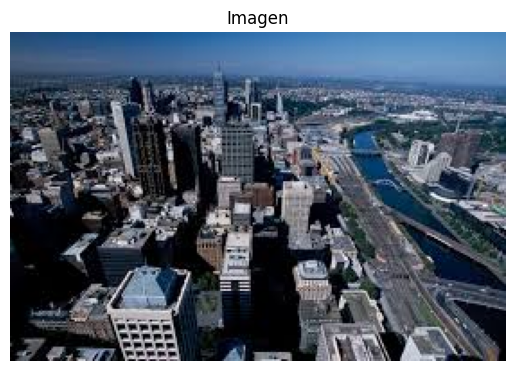

In [11]:
plt.imshow(Image.open("images_ciudad.jpg"))
plt.axis("off")
plt.title("Imagen")
plt.show()

## Aplicar deteccion de condición

#### Imagen con bordes

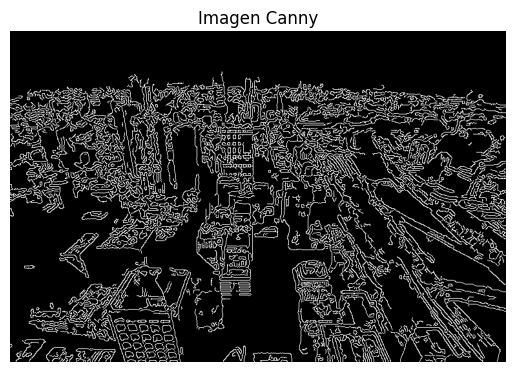

In [12]:
canny_detector = CannyDetector()

canny_image = canny_detector(canny_image_r)

plt.imshow(canny_image)
plt.axis("off")
plt.title("Imagen Canny")
plt.show()

#### Imagen con profundidad

In [13]:
depth_estimator = pipeline(
    "depth-estimation"
)

depth_image = depth_estimator(depth_image_r)["depth"]

No model was supplied, defaulted to Intel/dpt-large and revision bc15f29.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


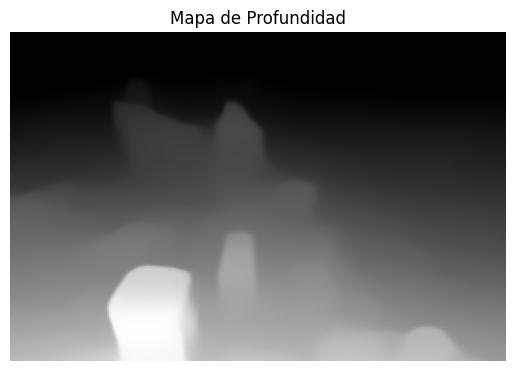

In [14]:
plt.imshow(depth_image, cmap="gray")
plt.axis("off")
plt.title("Mapa de Profundidad")
plt.show()

#### Imagen con pose

In [31]:
from controlnet_aux import OpenposeDetector

openpose = OpenposeDetector.from_pretrained(
    "lllyasviel/Annotators"
)

In [32]:
pose_image = openpose(pose_image_r)

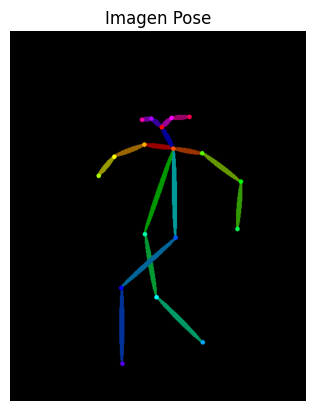

In [33]:
plt.imshow(pose_image)
plt.axis("off")
plt.title("Imagen Pose")
plt.show()

## Generar Imagen IA segun bordes

### Generación condicionada a Imagen y prompt

In [23]:
canny_prompt = "A cyberpunk city skyline at night"

result_canny = pipe(
    canny_prompt,
    image=canny_image,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

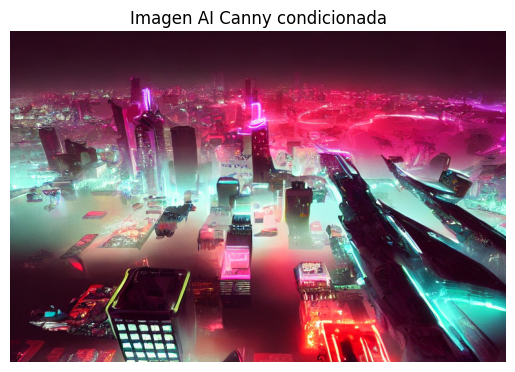

In [24]:
plt.imshow(result_canny)
plt.axis("off")
plt.title("Imagen AI Canny condicionada")
plt.show()

### Generación condicionada a solo prompt (Sin Imagen)

In [25]:
result_canny_sd = pipe_sd(
    canny_prompt,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

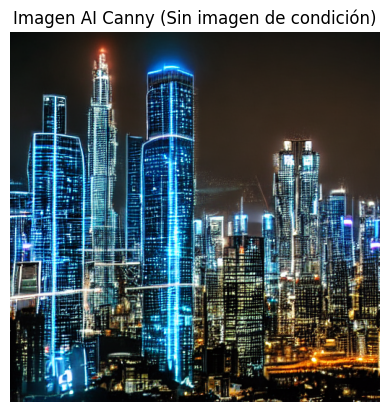

In [28]:
plt.imshow(result_canny_sd)
plt.axis("off")
plt.title("Imagen AI Canny (Sin imagen de condición)")
plt.show()

## Generación Imagen IA segun profundidad

### Generación condicionada a Imagen y Prompt

In [21]:
depth_prompt = "A cyberpunk city skyline at night"

result_depth = pipe_depth(
    depth_prompt,
    image=depth_image,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

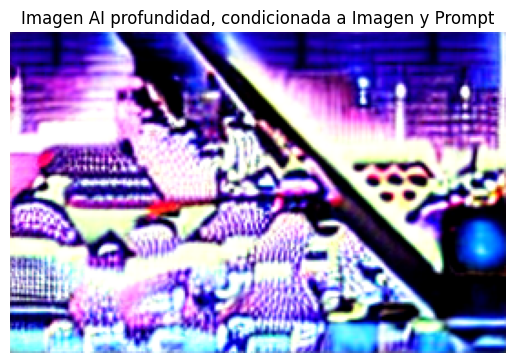

In [22]:
plt.imshow(result_depth)
plt.axis("off")
plt.title("Imagen AI profundidad, condicionada a Imagen y Prompt")
plt.show()

### Generación condicionada solo a prompt (Sin imagen)

In [23]:
depth_prompt = "A cyberpunk city skyline at night"

result_depth_sd = pipe_sd(
    depth_prompt,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

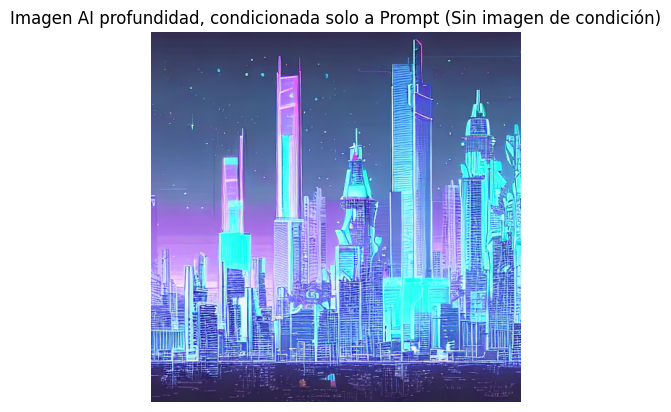

In [24]:
plt.imshow(result_depth_sd)
plt.axis("off")
plt.title("Imagen AI profundidad, condicionada solo a Prompt (Sin imagen de condición)")
plt.show()

## Generar Imagen IA segun Pose

In [37]:
pose_prompt = "A private detective standing in front of a dark alley in 1940"

result_pose = pipe_pose(
    pose_prompt,
    image=pose_image,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

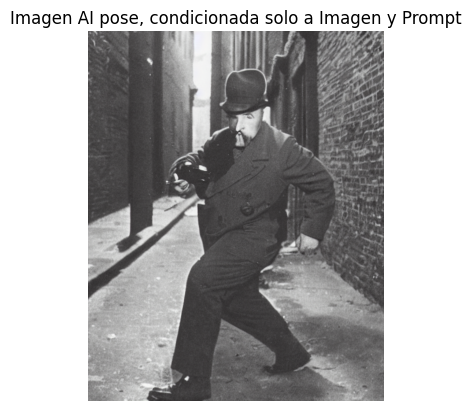

In [38]:
plt.imshow(result_pose)
plt.axis("off")
plt.title("Imagen AI pose, condicionada solo a Imagen y Prompt")
plt.show()

### Generación condicionada solo a prompt (Sin imagen)

In [41]:
pose_prompt = "A private detective standing in front of a dark alley in 1940"

result_pose_sd = pipe_sd(
    pose_prompt,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

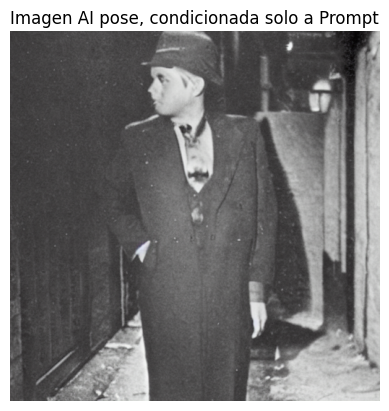

In [42]:
plt.imshow(result_pose_sd)
plt.axis("off")
plt.title("Imagen AI pose, condicionada solo a Prompt")
plt.show()